# Pfynwald HyPlant Co-registration Workflow

This notebook performs geometric co-registration of HyPlant imagery to a UAV
reference image using AROSICS.

For products used directly for registration, a structural-gradient proxy is
generated from a product-specific matching band and compared with a 1 m UAV
structural-gradient reference. AROSICS COREG_LOCAL estimates local tie-point
shifts, from which a robust global x/y translation is derived.

Products that share the same native acquisition geometry can inherit the
registration solution of a structurally more suitable source product. In
particular, vegetation-index (VI) products inherit the x/y translation of the
corresponding TOC_REFL acquisition rather than estimating a separate
registration from the VI values themselves.

The workflow then:

1. Estimates or inherits a global x/y translation.
2. Applies this translation to the native raster by updating its geotransform
   without resampling the original pixel values.
3. Crops and masks the shifted raster to the study area.
4. Resamples the co-registered raster once onto a common shared grid.
5. Stores registration provenance and QC information.
6. Generates visual diagnostics.

Outputs are organized into separate directories for:

- `native_grid/` — co-registered rasters on their native pixel grid, without interpolation
- `shared_grid/` — co-registered rasters resampled to the common analysis grid
- `registration_proxies/` — structural-gradient images used for matching
- `qc/` — tie-point tables, registration summaries and diagnostic results

UAV reference products and the shared-grid template are stored separately under the co-registration base directory.


#### Installation Notes — AROSICS on Windows

Installing **AROSICS** on Windows can be tricky due to dependencies like **GDAL**.  
Here’s the setup process that worked reliably for me:

```bash
# Create a new conda environment (Python 3.11)
conda create -c conda-forge --name arosics python=3.11
conda activate arosics

# Install GDAL first (this is often the main issue on Windows)
pip install gdal-installer
gdal-installer  # command-line setup for GDAL binaries

# Install required dependencies individually
pip install cartopy geopandas joblib matplotlib numpy pandas pyproj scikit-image shapely

# Finally, install AROSICS itself
pip install arosics
```

**Note:**  
The recommended installation via conda:

```bash
conda install -c conda-forge 'arosics>=1.3.0'
```

did **not** work for me due to the failing installation of GDAL.  


For further information, troubleshooting, and documentation, see: [AROSICS Official Documentation](https://danschef.git-pages.gfz-potsdam.de/arosics/doc/index.html)

In [85]:
from pathlib import Path
import logging
import re

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import rasterio
from affine import Affine
from arosics import COREG_LOCAL
from rasterio.errors import WindowError
from rasterio.features import geometry_mask
from rasterio.plot import show
from rasterio.warp import Resampling, calculate_default_transform, reproject, transform_bounds
from rasterio.windows import Window, from_bounds, transform as window_transform
from scipy.ndimage import binary_erosion, gaussian_filter, sobel

logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

In [ ]:
# --- Configuration ---

BASE_SHIFT_DIR = Path(r"E:/Proj1_Pfynwald_Data/HyPlant/original")
COREG_DIR_BASE = Path(r"E:/Proj1_Pfynwald_Data/HyPlant/coregistration")

UAV_IMAGE_PATH = Path(
    r"E:/Proj1_Pfynwald_Data/Drone_Data/PfynwaldCompressed/"
    r"20240823_Pfynwald_rgb_ortho_1cm_dem5cm.tif"
)

STUDY_AREA_PATH = Path(
    r"E:/Proj1_Pfynwald_Data/General/studyarea.gpkg"
)


# ------------------------------------------------------------
# Products to process
# ------------------------------------------------------------

FOLDERS = [
    "SIF_iFLD",
    "SIF_SFM",
    "SIF_SFMNN",
    "TOC_REFL",
    "VI",
    "TASI",
]

RASTER_EXTENSIONS = {".dat", ".bsq", ".bil"}


# ------------------------------------------------------------
# Product-specific configuration
# ------------------------------------------------------------

PRODUCT_CONFIG = {
    "TOC_REFL": {
        "nodata": -999,
        "match_band": None,
        "match_wavelength_nm": 737.0,
        "uav_proxy": "exg",
    },
    "SIF_SFM": {
        "nodata": -999,
        "match_band": 2,
        "match_wavelength_nm": None,
        "uav_proxy": "exg",
    },
    "SIF_SFMNN": {
        "nodata": -999,
        "match_band": 11,
        "match_wavelength_nm": None,
        "uav_proxy": "exg",
    },
    "SIF_iFLD": {
        "nodata": -999,
        "match_band": 3,
        "match_wavelength_nm": None,
        "uav_proxy": "exg",
    },
    "VI": {
        "nodata": -999,

        # Do not estimate registration directly from VI.
        # Use the corresponding TOC_REFL acquisition instead.
        "shift_source": "TOC_REFL",

        "match_band": None,
        "match_wavelength_nm": None,
        "uav_proxy": None,
    },
    "TASI": {
        "nodata": 0,
        "match_band": 1,
        "match_wavelength_nm": None,
        "uav_proxy": "gray",
    },
}


# ------------------------------------------------------------
# UAV proxy settings
# ------------------------------------------------------------

UAV_NODATA = 255
UAV_PROXY_CRS = "EPSG:32632"
UAV_PROXY_RES = 1.0

PROXY_NODATA = -9999.0
PROXY_SMOOTHING_SIGMA_M = 2.0
REBUILD_UAV_PROXIES = False


# ------------------------------------------------------------
# AROSICS settings
# ------------------------------------------------------------

COREG_WINDOW_SIZE = (48, 48)
COREG_MAX_SHIFT = 14
COREG_MAX_ITER = 5

LOCAL_GRID_RES = 8
LOCAL_MAX_POINTS = None

MIN_RELIABILITY = 0
MIN_TIEPOINTS = 10


# ------------------------------------------------------------
# QC settings
# ------------------------------------------------------------

QC_OK_MIN_TIEPOINTS = 15
QC_OK_MIN_RELIABILITY = 25
QC_OK_MAX_DEVIATION_M = 1.5


# ------------------------------------------------------------
# Shared-grid settings
# ------------------------------------------------------------

SHARED_GRID_CRS = "EPSG:32632"
SHARED_GRID_RES = 2.0
SHARED_GRID_RESAMPLING = "lanczos"


# ------------------------------------------------------------
# Product-independent output paths
# ------------------------------------------------------------

UAV_REFERENCE_DIR = COREG_DIR_BASE / "_uav_reference"
SHARED_GRID_DIR_BASE = COREG_DIR_BASE / "_shared_grid"

proxy_tag = (
    f"{UAV_PROXY_RES:g}m_"
    f"s{PROXY_SMOOTHING_SIGMA_M:g}m"
)

UAV_PROXY_PATHS = {
    "exg": UAV_REFERENCE_DIR / f"UAV_ExG_gradient_{proxy_tag}.tif",
    "gray": UAV_REFERENCE_DIR / f"UAV_gray_gradient_{proxy_tag}.tif",
}

SHARED_GRID_TEMPLATE_PATH = (
    SHARED_GRID_DIR_BASE
    / f"shared_grid_{SHARED_GRID_RES:g}m_EPSG32632.tif"
)

In [87]:
# --- Generic helpers ---

def _clean_tags(tags):
    return {k: v for k, v in tags.items() if not k.upper().startswith("STATISTICS_")}


def copy_metadata(src, dst):
    for i, description in enumerate(src.descriptions or (), start=1):
        if i <= dst.count and description:
            dst.set_band_description(i, description)
        if i <= dst.count:
            tags = _clean_tags(src.tags(i))
            if tags:
                dst.update_tags(i, **tags)

    for ns in (None, "ENVI"):
        tags = _clean_tags(src.tags() if ns is None else src.tags(ns=ns))
        if tags:
            if ns is None:
                dst.update_tags(**tags)
            else:
                dst.update_tags(ns=ns, **tags)

    try:
        dst.scales = src.scales
        dst.offsets = src.offsets
    except Exception:
        pass

    for i, unit in enumerate(src.units or (), start=1):
        if i <= dst.count and unit:
            try:
                dst.set_band_unit(i, unit)
            except Exception:
                pass


def assert_north_up(src):
    if not np.isclose(src.transform.b, 0) or not np.isclose(src.transform.d, 0):
        raise ValueError(f"Rotated raster grid is not supported without resampling: {src.name}")


def load_aoi_geometry(path, crs):
    aoi = gpd.read_file(path)
    if aoi.crs is None or crs is None:
        raise ValueError(f"Missing CRS for AOI or raster: {path}")
    if aoi.crs != crs:
        aoi = aoi.to_crs(crs)
    if aoi.empty:
        raise ValueError(f"Empty AOI: {path}")
    return aoi.geometry.union_all()


def make_gradient_proxy(arr, valid, sigma=1.0):
    arr = np.asarray(arr, dtype="float32")
    valid = np.asarray(valid, dtype=bool) & np.isfinite(arr)
    if not valid.any():
        raise ValueError("No valid pixels for proxy creation.")

    p02, p98 = np.percentile(arr[valid], [2, 98])
    if p98 <= p02:
        raise ValueError("Insufficient image contrast for proxy creation.")

    norm = np.clip((arr - p02) / (p98 - p02), 0, 1)
    work = np.where(valid, norm, np.median(norm[valid]))
    smooth = gaussian_filter(work, sigma=sigma)
    grad = np.hypot(sobel(smooth, axis=1, mode="nearest"), sobel(smooth, axis=0, mode="nearest"))
    grad[~binary_erosion(valid, iterations=2, border_value=0)] = np.nan

    good = np.isfinite(grad)
    if good.any():
        g02, g98 = np.percentile(grad[good], [2, 98])
        if g98 > g02:
            grad[good] = np.clip((grad[good] - g02) / (g98 - g02), 0, 1)
    return grad.astype("float32")


def _numbers(text):
    return [float(x) for x in re.findall(r"[-+]?(?:\d*\.\d+|\d+\.?)(?:[eE][-+]?\d+)?", str(text))]


def select_match_band(src, product):
    if product["match_band"] is not None:
        band = int(product["match_band"])
        if not 1 <= band <= src.count:
            raise ValueError(f"Match band {band} outside 1..{src.count}: {src.name}")
        return band

    target = product["match_wavelength_nm"]
    envi = {k.lower().replace(" ", "_"): v for k, v in src.tags(ns="ENVI").items()}
    wavelengths = _numbers(envi.get("wavelength", ""))

    if len(wavelengths) == src.count:
        units = envi.get("wavelength_units", "").lower()
        if "micro" in units or (not units and np.nanmedian(wavelengths) < 10):
            wavelengths = [w * 1000 for w in wavelengths]
        return int(np.argmin(np.abs(np.asarray(wavelengths) - target))) + 1

    candidates = []
    for i, description in enumerate(src.descriptions or (), start=1):
        vals = [x for x in _numbers(description) if 300 <= x <= 2500]
        if vals:
            candidates.append((abs(vals[-1] - target), i))
    if candidates:
        return min(candidates)[1]

    raise ValueError(
        f"Cannot identify the band nearest {target:g} nm in {src.name}. "
        "Set match_band explicitly in PRODUCT_CONFIG."
    )


def write_proxy(path, array, crs, transform, description):
    path.parent.mkdir(parents=True, exist_ok=True)
    data = np.where(np.isfinite(array), array, PROXY_NODATA).astype("float32")
    profile = dict(
        driver="GTiff", height=data.shape[0], width=data.shape[1], count=1,
        dtype="float32", crs=crs, transform=transform, nodata=PROXY_NODATA,
        compress="LZW", BIGTIFF="IF_SAFER",
    )
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(data, 1)
        dst.set_band_description(1, description)


# Acquisition and shared-geometry helpers
ACQUISITION_PATTERN = re.compile(
    r"\d{8}-PHY-\d{4}-\d{4}-L\d-[EW]"
)


def acquisition_id(value):
    """
    Extract HyPlant acquisition ID, e.g.
    20240823-PHY-1248-1340-L1-E
    """
    m = ACQUISITION_PATTERN.search(str(value))

    if m is None:
        raise ValueError(
            f"Could not extract acquisition ID from: {value}"
        )

    return m.group(0)


def assert_same_grid(path_a, path_b):
    """
    Confirm that two original products use exactly the same
    nominal raster geometry before propagating a shift.
    """
    with rasterio.open(path_a) as a, rasterio.open(path_b) as b:

        checks = {
            "CRS": a.crs == b.crs,

            "shape": (
                a.width == b.width
                and a.height == b.height
            ),

            "transform": np.allclose(
                tuple(a.transform),
                tuple(b.transform),
                atol=1e-8,
                rtol=0,
            ),

            "resolution": np.allclose(
                a.res,
                b.res,
                atol=1e-8,
                rtol=0,
            ),

            "bounds": np.allclose(
                tuple(a.bounds),
                tuple(b.bounds),
                atol=1e-6,
                rtol=0,
            ),
        }

    failed = [
        name
        for name, ok in checks.items()
        if not ok
    ]

    if failed:
        raise ValueError(
            "Cannot inherit registration because raster grids "
            f"differ in {', '.join(failed)}:\n"
            f"  source: {path_a}\n"
            f"  target: {path_b}"
        )

Building UAV reference products...
✓ UAV reference products created
✓ Reusing existing shared grid
UAV reference grid: 331 × 462 | EPSG:32632 | (1.0, 1.0)
Shared grid: 436 × 310 | EPSG:32632 | (2.0, 2.0)
Available UAV matching proxies:
  exg: E:\Proj1_Pfynwald_Data\HyPlant\coregistration\_uav_reference\UAV_ExG_gradient_1m_s2m.tif
  gray: E:\Proj1_Pfynwald_Data\HyPlant\coregistration\_uav_reference\UAV_gray_gradient_1m_s2m.tif


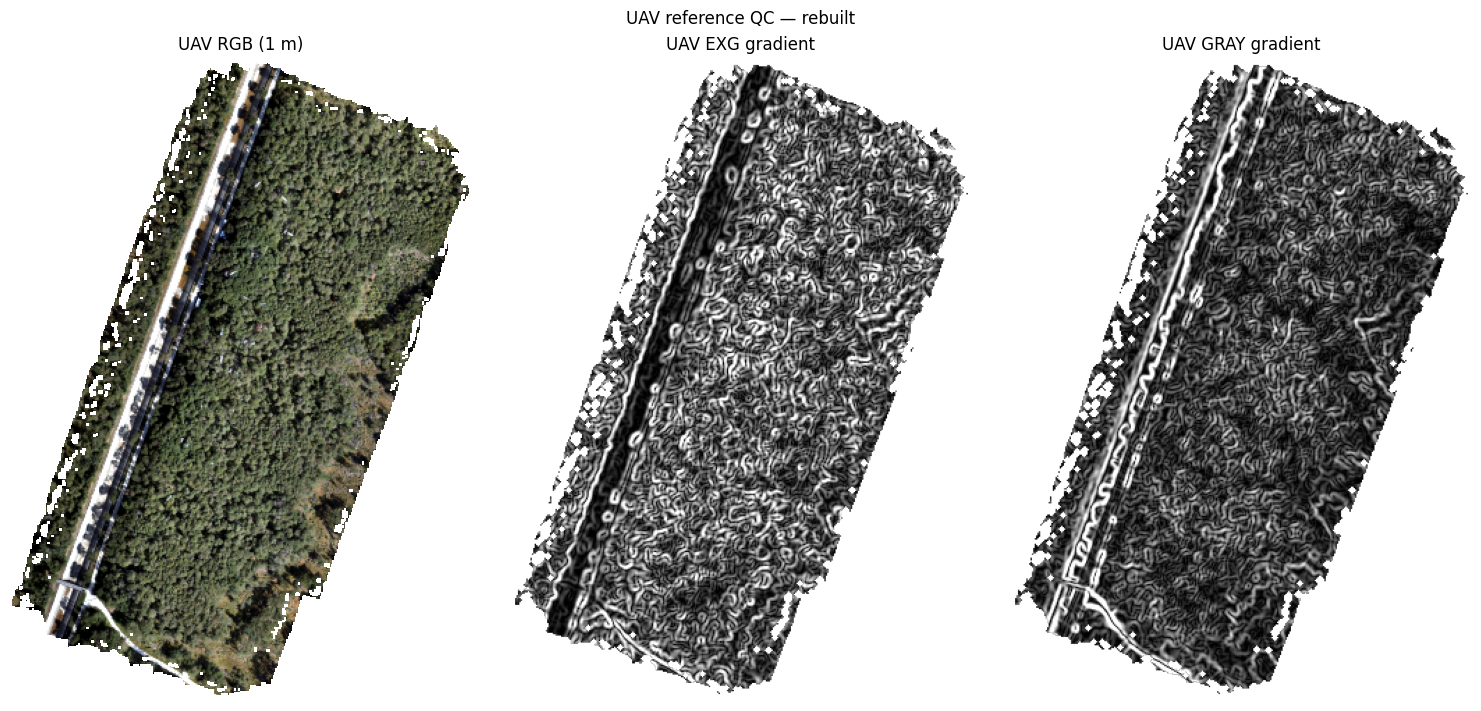

In [88]:
# --- UAV reference products and fixed shared grid ---

UAV_RGB_REFERENCE_PATH = UAV_REFERENCE_DIR / f"UAV_RGB_{UAV_PROXY_RES:g}m.tif"


def grid_matches(path, crs, transform, width, height, count=1):
    if not path.exists():
        return False
    try:
        with rasterio.open(path) as src:
            return (
                src.crs == rasterio.crs.CRS.from_string(crs)
                and src.width == width
                and src.height == height
                and src.count == count
                and np.allclose(tuple(src.transform), tuple(transform))
            )
    except Exception:
        return False


def ensure_uav_reference():

    UAV_REFERENCE_DIR.mkdir(parents=True, exist_ok=True)

    # Expected 1 m UAV grid
    with rasterio.Env(GTIFF_SRS_SOURCE="EPSG"):
        with rasterio.open(UAV_IMAGE_PATH) as src:
            transform, width, height = calculate_default_transform(
                src.crs, UAV_PROXY_CRS,
                src.width, src.height, *src.bounds,
                resolution=UAV_PROXY_RES,
            )

    paths_ok = (
        grid_matches(UAV_RGB_REFERENCE_PATH, UAV_PROXY_CRS, transform, width, height, 3)
        and grid_matches(UAV_PROXY_PATHS["gray"], UAV_PROXY_CRS, transform, width, height)
        and grid_matches(UAV_PROXY_PATHS["exg"], UAV_PROXY_CRS, transform, width, height)
    )

    if paths_ok and not REBUILD_UAV_PROXIES:
        print("✓ Reusing existing UAV reference products")
        return False

    print("Building UAV reference products...")

    # Reproject UAV RGB once
    rgb = []

    with rasterio.Env(GTIFF_SRS_SOURCE="EPSG"):
        with rasterio.open(UAV_IMAGE_PATH) as src:

            if src.count < 3:
                raise ValueError("UAV image must contain RGB bands 1, 2 and 3.")

            src_nodata = src.nodata if src.nodata is not None else UAV_NODATA

            for band in (1, 2, 3):
                dst = np.full((height, width), np.nan, dtype="float32")

                reproject(
                    source=rasterio.band(src, band),
                    destination=dst,
                    src_transform=src.transform,
                    src_crs=src.crs,
                    src_nodata=src_nodata,
                    dst_transform=transform,
                    dst_crs=UAV_PROXY_CRS,
                    dst_nodata=np.nan,
                    resampling=Resampling.average,
                    num_threads=4,
                )

                rgb.append(dst)

    rgb = np.stack(rgb)
    r, g, b = rgb
    valid = np.all(np.isfinite(rgb), axis=0)

    # Save cached 1 m RGB
    rgb_out = np.where(np.isfinite(rgb), rgb, PROXY_NODATA).astype("float32")

    with rasterio.open(
        UAV_RGB_REFERENCE_PATH,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=3,
        dtype="float32",
        crs=UAV_PROXY_CRS,
        transform=transform,
        nodata=PROXY_NODATA,
        compress="DEFLATE",
    ) as dst:
        dst.write(rgb_out)
        dst.write_mask(valid.astype("uint8") * 255)

    # Structural proxies
    gray = 0.299 * r + 0.587 * g + 0.114 * b
    exg = 2 * g - r - b

    for name, arr in {"gray": gray, "exg": exg}.items():
        write_proxy(
            UAV_PROXY_PATHS[name],
            make_gradient_proxy(arr, valid, PROXY_SMOOTHING_SIGMA),
            UAV_PROXY_CRS,
            transform,
            f"UAV {name} structural gradient",
        )

    print("✓ UAV reference products created")
    return True


def ensure_shared_grid_template():

    SHARED_GRID_DIR_BASE.mkdir(parents=True, exist_ok=True)

    # Shared grid is product-independent.
    # Use the fixed 1 m UAV RGB grid as the spatial anchor.
    with rasterio.open(UAV_RGB_REFERENCE_PATH) as ref:

        if ref.crs != rasterio.crs.CRS.from_string(SHARED_GRID_CRS):
            raise ValueError("Shared grid CRS must match UAV reference CRS.")

        minx, miny, maxx, maxy = load_aoi_geometry(
            STUDY_AREA_PATH, ref.crs
        ).bounds

        x0, y0 = ref.transform.c, ref.transform.f

    res = SHARED_GRID_RES

    left   = x0 + np.floor((minx - x0) / res) * res
    right  = x0 + np.ceil((maxx - x0) / res) * res
    bottom = y0 + np.floor((miny - y0) / res) * res
    top    = y0 + np.ceil((maxy - y0) / res) * res

    width = int(round((right - left) / res))
    height = int(round((top - bottom) / res))
    transform = rasterio.transform.from_origin(left, top, res, res)

    if grid_matches(
        SHARED_GRID_TEMPLATE_PATH,
        SHARED_GRID_CRS,
        transform,
        width,
        height,
    ):
        print("✓ Reusing existing shared grid")
        return

    with rasterio.open(
        SHARED_GRID_TEMPLATE_PATH,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=1,
        dtype="uint8",
        crs=SHARED_GRID_CRS,
        transform=transform,
        nodata=0,
        compress="LZW",
    ) as dst:
        dst.write(np.zeros((height, width), dtype="uint8"), 1)
        dst.update_tags(role="grid_template")

    print("✓ Shared grid created")

# --- Build or reuse ---

uav_rebuilt = ensure_uav_reference()
ensure_shared_grid_template()

with rasterio.open(UAV_RGB_REFERENCE_PATH) as ref, \
     rasterio.open(SHARED_GRID_TEMPLATE_PATH) as grid:

    print(
        f"UAV reference grid: "
        f"{ref.width} × {ref.height} | {ref.crs} | {ref.res}"
    )

    print(
        f"Shared grid: "
        f"{grid.width} × {grid.height} | {grid.crs} | {grid.res}"
    )

print("Available UAV matching proxies:")
for name, path in UAV_PROXY_PATHS.items():
    print(f"  {name}: {path}")

# ============================================================
# Quick QC view — UAV references
# ============================================================

def stretch(arr):
    out = np.zeros_like(arr, dtype="float32")

    for i in range(arr.shape[0]):
        valid = np.isfinite(arr[i])

        if not np.any(valid):
            continue

        lo, hi = np.nanpercentile(arr[i][valid], [2, 98])

        if hi > lo:
            out[i] = np.clip(
                (arr[i] - lo) / (hi - lo),
                0,
                1,
            )

    return np.moveaxis(out, 0, -1)


# RGB
with rasterio.open(UAV_RGB_REFERENCE_PATH) as src:
    rgb = (
        src.read(masked=True)
        .astype("float32")
        .filled(np.nan)
    )

    extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    ]


# Matching proxies
proxies = {}

for name, path in UAV_PROXY_PATHS.items():
    with rasterio.open(path) as src:
        proxies[name] = (
            src.read(1, masked=True)
            .astype("float32")
            .filled(np.nan)
        )


# Plot
fig, ax = plt.subplots(
    1,
    3,
    figsize=(15, 7),
    constrained_layout=True,
)

ax[0].imshow(
    stretch(rgb),
    extent=extent,
    origin="upper",
)
ax[0].set_title(f"UAV RGB ({UAV_PROXY_RES:g} m)")


for a, name in zip(ax[1:], ("exg", "gray")):

    proxy = proxies[name]
    valid = np.isfinite(proxy)

    vmin, vmax = np.nanpercentile(
        proxy[valid],
        [2, 98],
    )

    a.imshow(
        proxy,
        extent=extent,
        origin="upper",
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
    )

    a.set_title(f"UAV {name.upper()} gradient")


for a in ax:
    a.set_aspect("equal")
    a.axis("off")


fig.suptitle(
    f"UAV reference QC — "
    f"{'rebuilt' if uav_rebuilt else 'reused'}"
)

plt.show()

In [89]:
# --- Inputs and output folders ---

def setup_folder(folder):
    global FOLDER, PRODUCT, INPUT_DIR, shift_images
    global OUT_DIR, NATIVE_COREG_DIR, SHARED_GRID_DIR, PROXY_DIR, QC_DIR
    global UAV_REFERENCE_PROXY_PATH
    global SHIFT_SOURCE_PRODUCT

    if folder not in PRODUCT_CONFIG:
        raise ValueError(f"Unknown product: {folder}")

    # Current product
    FOLDER = folder
    PRODUCT = PRODUCT_CONFIG[folder]

    # Optional external source of the geometric shift
    SHIFT_SOURCE_PRODUCT = PRODUCT.get("shift_source")

    # Input
    INPUT_DIR = BASE_SHIFT_DIR / folder

    # Product-specific outputs
    OUT_DIR = COREG_DIR_BASE / folder
    NATIVE_COREG_DIR = OUT_DIR / "native_grid"
    SHARED_GRID_DIR = OUT_DIR / "shared_grid"
    PROXY_DIR = OUT_DIR / "registration_proxies"
    QC_DIR = OUT_DIR / "qc"

    # UAV proxy is required only when this product estimates
    # its own registration.
    if SHIFT_SOURCE_PRODUCT is None:

        uav_proxy = PRODUCT["uav_proxy"]

        if uav_proxy is None:
            raise ValueError(
                f"{folder} requires direct matching but no "
                "uav_proxy is configured."
            )

        UAV_REFERENCE_PROXY_PATH = UAV_PROXY_PATHS[uav_proxy]

        registration_text = (
            f"direct AROSICS matching ({uav_proxy})"
        )

    else:

        UAV_REFERENCE_PROXY_PATH = None

        registration_text = (
            f"inherited from {SHIFT_SOURCE_PRODUCT}"
        )

    if not INPUT_DIR.exists():
        raise FileNotFoundError(
            f"Input directory does not exist: {INPUT_DIR}"
        )

    shift_images = sorted(
        p for p in INPUT_DIR.iterdir()
        if p.is_file()
        and p.suffix.lower() in RASTER_EXTENSIONS
    )

    if not shift_images:
        raise FileNotFoundError(
            f"No supported rasters found in {INPUT_DIR}"
        )

    for directory in (
        NATIVE_COREG_DIR,
        SHARED_GRID_DIR,
        PROXY_DIR,
        QC_DIR,
    ):
        directory.mkdir(
            parents=True,
            exist_ok=True,
        )

    print(
        f"\n{'=' * 60}\n"
        f"Product:      {FOLDER}\n"
        f"Images:       {len(shift_images)}\n"
        f"Input:        {INPUT_DIR}\n"
        f"Output:       {OUT_DIR}\n"
        f"Registration: {registration_text}\n"
        f"{'=' * 60}"
    )

In [ ]:
# --- Registration helpers ---

def load_shift_source_summary(source_product):
    """
    Load the QC summary of a product whose shifts will be
    inherited by another product.
    """

    summary_path = (
        COREG_DIR_BASE
        / source_product
        / "qc"
        / "coreg_summary.csv"
    )

    if not summary_path.exists():
        raise FileNotFoundError(
            f"Registration source summary not found:\n"
            f"{summary_path}\n\n"
            f"Run {source_product} co-registration first."
        )

    summary = pd.read_csv(summary_path)

    required = {
        "image",
        "status",
        "x_shift_map",
        "y_shift_map",
    }

    missing = required - set(summary.columns)

    if missing:
        raise ValueError(
            f"{source_product} summary is missing columns: "
            f"{sorted(missing)}"
        )

    summary["acquisition"] = (
        summary["image"]
        .apply(acquisition_id)
    )

    duplicates = (
        summary["acquisition"]
        .duplicated(keep=False)
    )

    if duplicates.any():
        duplicate_ids = (
            summary.loc[duplicates, "acquisition"]
            .unique()
        )

        raise ValueError(
            f"Duplicate acquisitions in "
            f"{source_product} summary: "
            f"{duplicate_ids.tolist()}"
        )

    return summary.set_index(
        "acquisition",
        drop=False,
    )

def make_target_proxy(src_path, out_path):
    with rasterio.open(src_path) as src:
        assert_north_up(src)

        band = select_match_band(src, PRODUCT)
        arr = src.read(band).astype("float32")
        valid = src.read_masks(band) > 0

        nodata = PRODUCT["nodata"]
        if nodata is not None:
            valid &= arr != nodata

        # Convert smoothing scale from metres to pixels
        pixel_size_m = abs(src.transform.a)
        sigma_px = PROXY_SMOOTHING_SIGMA_M / pixel_size_m

        proxy = make_gradient_proxy(
            arr,
            valid,
            sigma_px,
        )

        write_proxy(
            out_path,
            proxy,
            src.crs,
            src.transform,
            (
                f"Target structural gradient; "
                f"source band {band}; "
                f"smoothing {PROXY_SMOOTHING_SIGMA_M:g} m"
            ),
        )

    return band


def _round_window_outward(window):
    c0, r0 = np.floor([window.col_off, window.row_off]).astype(int)
    c1 = int(np.ceil(window.col_off + window.width))
    r1 = int(np.ceil(window.row_off + window.height))
    return Window(c0, r0, c1 - c0, r1 - r0)

# --- Registration ---

def estimate_global_shift(ref_path, tgt_path):
    crl = COREG_LOCAL(
        str(ref_path),
        str(tgt_path),
        grid_res=LOCAL_GRID_RES,
        max_points=LOCAL_MAX_POINTS,
        window_size=COREG_WINDOW_SIZE,
        r_b4match=1,
        s_b4match=1,
        max_iter=COREG_MAX_ITER,
        max_shift=COREG_MAX_SHIFT,
        nodata=(PROXY_NODATA, PROXY_NODATA),

        tieP_filter_level=3,
        min_reliability=MIN_RELIABILITY,
        tieP_random_state=0,
        rs_random_state=0,

        align_grids=False,
        match_gsd=False,
        resamp_alg_calc="cubic",

        binary_ws=False,
        force_quadratic_win=True,

        progress=False,
        q=True,
        ignore_errors=True,
    )

    crl.calculate_spatial_shifts()

    matches = crl.CoRegPoints_table.copy()

    if matches.empty:
        raise RuntimeError("AROSICS found no tie points.")

    # Valid numerical shifts
    valid = (
        matches["X_SHIFT_M"].notna()
        & matches["Y_SHIFT_M"].notna()
        & (matches["X_SHIFT_M"] != PROXY_NODATA)
        & (matches["Y_SHIFT_M"] != PROXY_NODATA)
    )

    # 1. Final AROSICS inliers: SSIM + RANSAC etc.
    arosics_good = valid & matches["OUTLIER"].eq(False)
    matches["arosics_inlier"] = arosics_good

    if arosics_good.sum() < MIN_TIEPOINTS:
        raise RuntimeError(
            f"Only {int(arosics_good.sum())} valid AROSICS tie points."
        )

    # 2. Robust centre of AROSICS inliers
    dx0 = matches.loc[arosics_good, "X_SHIFT_M"].median()
    dy0 = matches.loc[arosics_good, "Y_SHIFT_M"].median()

    dev0 = np.hypot(
        matches["X_SHIFT_M"] - dx0,
        matches["Y_SHIFT_M"] - dy0,
    )

    # 3. Translation-specific robust filter
    d = dev0[arosics_good]

    med_dev = d.median()
    mad_dev = np.median(np.abs(d - med_dev))

    threshold = max(
        1.5,                         # minimum tolerance [m]
        med_dev + 3 * 1.4826 * mad_dev
    )

    translation_good = arosics_good & (dev0 <= threshold)

    matches["translation_inlier"] = translation_good
    matches["used"] = translation_good

    if translation_good.sum() < MIN_TIEPOINTS:
        raise RuntimeError(
            f"Only {int(translation_good.sum())} translation-consistent tie points."
        )

    # 4. Final global translation
    dx = float(matches.loc[translation_good, "X_SHIFT_M"].median())
    dy = float(matches.loc[translation_good, "Y_SHIFT_M"].median())

    # Final deviations for QC
    matches["deviation_from_median_m"] = np.hypot(
        matches["X_SHIFT_M"] - dx,
        matches["Y_SHIFT_M"] - dy,
    )

    return dx, dy, matches

In [76]:
# --- Output helpers ---

def _gtiff_profile(src, **updates):
    profile = src.profile.copy()
    for key in ("blockxsize", "blockysize", "tiled", "interleave"):
        profile.pop(key, None)
    profile.update(driver="GTiff", compress="LZW", BIGTIFF="IF_SAFER", **updates)
    return profile


def write_native_coreg(
    src_path,
    out_path,
    dx,
    dy,
    registration_source=None,
    source_image=None,
    source_status=None,
):
    with rasterio.open(src_path) as src:
        assert_north_up(src)
        shifted = Affine.translation(dx, dy) * src.transform
        geom = load_aoi_geometry(STUDY_AREA_PATH, src.crs)

        window = _round_window_outward(from_bounds(*geom.bounds, transform=shifted))
        try:
            window = window.intersection(Window(0, 0, src.width, src.height))
        except WindowError as exc:
            raise ValueError("Shifted raster does not overlap the study area.") from exc

        data = src.read(window=window)
        transform = window_transform(window, shifted)
        inside = geometry_mask([geom.__geo_interface__], data.shape[1:], transform, invert=True)
        nodata = PRODUCT["nodata"] if PRODUCT["nodata"] is not None else src.nodata
        if nodata is None:
            raise ValueError("A NoData value is required for the native AOI crop.")
        data[:, ~inside] = np.asarray(nodata, dtype=data.dtype)

        profile = _gtiff_profile(
            src, height=data.shape[1], width=data.shape[2], transform=transform, nodata=nodata,
        )
        with rasterio.open(
            out_path,
            "w",
            **profile,
        ) as dst:

            dst.write(data)
            copy_metadata(src, dst)

            tags = {
                "coreg_reference": "UAV",
                "coreg_shift_x_map": dx,
                "coreg_shift_y_map": dy,
                "coreg_resampled": "false",
            }

            if registration_source is not None:
                tags["coreg_shift_source_product"] = (
                    registration_source
                )

            if source_image is not None:
                tags["coreg_shift_source_image"] = (
                    source_image
                )

            if source_status is not None:
                tags["coreg_shift_source_status"] = (
                    source_status
                )

            dst.update_tags(**tags)

def resample_to_shared_grid(src_path, out_path):
    resampling = getattr(Resampling, SHARED_GRID_RESAMPLING)
    with rasterio.open(src_path) as src, rasterio.open(SHARED_GRID_TEMPLATE_PATH) as grid:
        profile = _gtiff_profile(
            src, height=grid.height, width=grid.width, crs=grid.crs,
            transform=grid.transform, nodata=src.nodata,
        )
        with rasterio.open(out_path, "w", **profile) as dst:
            for band in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, band), destination=rasterio.band(dst, band),
                    src_transform=src.transform, src_crs=src.crs, src_nodata=src.nodata,
                    dst_transform=grid.transform, dst_crs=grid.crs, dst_nodata=src.nodata,
                    resampling=resampling, num_threads=4,
                )
            copy_metadata(src, dst)
            dst.update_tags(coreg_resampled="true", shared_grid=str(SHARED_GRID_TEMPLATE_PATH),
                            shared_grid_resampling=SHARED_GRID_RESAMPLING)

In [79]:
# --- Run batch for all products ---

def process_folder():

    summary_rows = []
    match_tables = []

    source_summary = (
        load_shift_source_summary(SHIFT_SOURCE_PRODUCT)
        if SHIFT_SOURCE_PRODUCT is not None
        else None
    )

    for i, src_path in enumerate(shift_images, start=1):

        logger.info(
            "[%s | %d/%d] %s",
            FOLDER, i, len(shift_images), src_path.name,
        )

        native_path = NATIVE_COREG_DIR / f"{src_path.stem}_coreg_native.tif"
        shared_path = SHARED_GRID_DIR / f"{src_path.stem}_coreg_shared.tif"

        try:
            acq = acquisition_id(src_path.name)

            # -------------------------------------------------
            # Inherit shift from another product, e.g. VI <- REFL
            # -------------------------------------------------
            if SHIFT_SOURCE_PRODUCT is not None:

                if acq not in source_summary.index:
                    raise RuntimeError(
                        f"No {SHIFT_SOURCE_PRODUCT} solution for {acq}"
                    )

                src_row = source_summary.loc[acq]

                dx = src_row["x_shift_map"]
                dy = src_row["y_shift_map"]
                source_status = str(src_row["status"])

                if (
                    source_status == "FAILED"
                    or pd.isna(dx)
                    or pd.isna(dy)
                ):
                    raise RuntimeError(
                        f"No usable {SHIFT_SOURCE_PRODUCT} shift for {acq}"
                    )

                dx, dy = float(dx), float(dy)

                source_image = str(src_row["image"])
                source_input = (
                    BASE_SHIFT_DIR
                    / SHIFT_SOURCE_PRODUCT
                    / source_image
                )

                if not source_input.exists():
                    raise FileNotFoundError(source_input)

                assert_same_grid(source_input, src_path)

                registration_mode = "inherited"
                registration_source = SHIFT_SOURCE_PRODUCT
                status = source_status

                band = np.nan
                source_match_band = src_row.get("match_band", np.nan)

                n_arosics = src_row.get("n_arosics", np.nan)
                n_matches = src_row.get("n_matches", np.nan)
                retained_pct = src_row.get("retained_pct", np.nan)
                median_dev = src_row.get("median_dev_m", np.nan)
                p90_dev = src_row.get("p90_dev_m", np.nan)

                logger.info(
                    "%s <- %s: dx=%.2f, dy=%.2f (%s)",
                    acq,
                    SHIFT_SOURCE_PRODUCT,
                    dx,
                    dy,
                    status,
                )

            # -------------------------------------------------
            # Normal direct AROSICS registration
            # -------------------------------------------------
            else:

                proxy_path = PROXY_DIR / f"{src_path.stem}_gradient.tif"

                band = make_target_proxy(src_path, proxy_path)

                dx, dy, matches = estimate_global_shift(
                    UAV_REFERENCE_PROXY_PATH,
                    proxy_path,
                )

                matches.insert(0, "image", src_path.name)
                matches.insert(1, "acquisition", acq)
                match_tables.append(matches)

                aro = matches["arosics_inlier"]
                used = matches["translation_inlier"]

                n_arosics = int(aro.sum())
                n_matches = int(used.sum())

                retained_pct = (
                    100 * n_matches / n_arosics
                    if n_arosics else 0
                )

                dev = matches.loc[
                    used,
                    "deviation_from_median_m",
                ]

                median_dev = float(dev.median())
                p90_dev = float(dev.quantile(0.90))

                if n_matches < 15 or retained_pct < 50:
                    status = "POOR"
                elif (
                    retained_pct >= 70
                    and median_dev <= 1.0
                    and p90_dev <= 2.0
                ):
                    status = "GOOD"
                else:
                    status = "REVIEW"

                registration_mode = "estimated"
                registration_source = FOLDER
                source_image = src_path.name
                source_status = status
                source_match_band = band

            # -------------------------------------------------
            # Outputs
            # -------------------------------------------------
            write_native_coreg(
                src_path,
                native_path,
                dx,
                dy,
                registration_source=registration_source,
                source_image=source_image,
                source_status=source_status,
            )

            resample_to_shared_grid(
                native_path,
                shared_path,
            )

            summary_rows.append(dict(
                image=src_path.name,
                acquisition=acq,
                status=status,
                registration_mode=registration_mode,
                registration_source=registration_source,
                source_image=source_image,
                source_status=source_status,
                match_band=band,
                source_match_band=source_match_band,
                x_shift_map=dx,
                y_shift_map=dy,
                shift_m=np.hypot(dx, dy),
                n_arosics=n_arosics,
                n_matches=n_matches,
                retained_pct=retained_pct,
                median_dev_m=median_dev,
                p90_dev_m=p90_dev,
                native_output=str(native_path),
                shared_output=str(shared_path),
                error=None,
            ))

        except Exception as exc:

            logger.error("Failed %s: %s", src_path.name, exc)

            summary_rows.append(dict(
                image=src_path.name,
                acquisition=(
                    acquisition_id(src_path.name)
                    if acquisition_id else np.nan
                ),
                status="FAILED",
                registration_mode=(
                    "inherited"
                    if SHIFT_SOURCE_PRODUCT is not None
                    else "estimated"
                ),
                registration_source=(
                    SHIFT_SOURCE_PRODUCT or FOLDER
                ),
                error=str(exc),
            ))

    summary_df = pd.DataFrame(summary_rows)

    match_df = (
        pd.concat(match_tables, ignore_index=True)
        if match_tables
        else pd.DataFrame()
    )

    summary_df.to_csv(
        QC_DIR / "coreg_summary.csv",
        index=False,
    )

    matches_path = QC_DIR / "coreg_matches.csv"

    if not match_df.empty:
        match_df.to_csv(matches_path, index=False)
    elif matches_path.exists():
        matches_path.unlink()

    return summary_df, match_df


# ------------------------------------------------------------
# Run selected folders
# ------------------------------------------------------------

all_summaries = []
all_matches = {}

for folder in FOLDERS:

    setup_folder(folder)

    summary_df, match_df = process_folder()

    summary_df.insert(0, "product", folder)

    all_summaries.append(summary_df)
    all_matches[folder] = match_df

    print(
        f"✓ {folder}: "
        f"{(summary_df['status'] != 'FAILED').sum()}/"
        f"{len(summary_df)} processed"
    )


# ------------------------------------------------------------
# Combined overview
# ------------------------------------------------------------

all_summary_df = pd.concat(
    all_summaries,
    ignore_index=True,
)

display(
    all_summary_df.reindex(columns=[
        "product",
        "image",
        "status",
        "registration_mode",
        "registration_source",
        "shift_m",
        "n_matches",
        "retained_pct",
        "median_dev_m",
        "p90_dev_m",
    ]).round(2)
)

[INFO] [VI | 1/18] 20230617-PHY-1117-1360-L1-E-DUAL-rect_img_atm_pol_indices_up.bsq
[ERROR] Failed 20230617-PHY-1117-1360-L1-E-DUAL-rect_img_atm_pol_indices_up.bsq: Cannot inherit registration because raster grids differ in transform, bounds:
  source: E:\Proj1_Pfynwald_Data\HyPlant\original\TOC_REFL\20230617-PHY-1117-1360-L1-E-DUAL-rect_img_atm_pol.bsq
  target: E:\Proj1_Pfynwald_Data\HyPlant\original\VI\20230617-PHY-1117-1360-L1-E-DUAL-rect_img_atm_pol_indices_up.bsq
[INFO] [VI | 2/18] 20230617-PHY-1124-1360-L2-W-DUAL-rect_img_atm_pol_indices_up.bsq
[ERROR] Failed 20230617-PHY-1124-1360-L2-W-DUAL-rect_img_atm_pol_indices_up.bsq: Cannot inherit registration because raster grids differ in transform, bounds:
  source: E:\Proj1_Pfynwald_Data\HyPlant\original\TOC_REFL\20230617-PHY-1124-1360-L2-W-DUAL-rect_img_atm_pol.bsq
  target: E:\Proj1_Pfynwald_Data\HyPlant\original\VI\20230617-PHY-1124-1360-L2-W-DUAL-rect_img_atm_pol_indices_up.bsq
[INFO] [VI | 3/18] 20240613-PHY-1143-1340-L1-W-DUAL_


Product:      VI
Images:       18
Input:        E:\Proj1_Pfynwald_Data\HyPlant\original\VI
Output:       E:\Proj1_Pfynwald_Data\HyPlant\coregistration\VI
Registration: inherited from TOC_REFL


[INFO] [VI | 4/18] 20240613-PHY-1149-1340-L2-W-DUAL_radiance_img_atm_pol_indices_up-rect.bsq
[INFO] 20240613-PHY-1149-1340-L2-W <- TOC_REFL: dx=3.51, dy=-3.52 (GOOD)
[INFO] [VI | 5/18] 20240613-PHY-1154-1340-L2-E-DUAL_radiance_img_atm_pol_indices_up-rect.bsq
[INFO] 20240613-PHY-1154-1340-L2-E <- TOC_REFL: dx=-10.59, dy=2.30 (GOOD)
[INFO] [VI | 6/18] 20240613-PHY-1200-1340-L1-E-DUAL_radiance_img_atm_pol_indices_up-rect.bsq
[INFO] 20240613-PHY-1200-1340-L1-E <- TOC_REFL: dx=-9.59, dy=3.51 (GOOD)
[INFO] [VI | 7/18] 20240823-PHY-1248-1340-L1-E-DUAL_radiance_img_atm_pol_indices_up-rect.bsq
[INFO] 20240823-PHY-1248-1340-L1-E <- TOC_REFL: dx=-1.00, dy=-0.49 (GOOD)
[INFO] [VI | 8/18] 20240823-PHY-1253-1340-L2-E-DUAL_radiance_img_atm_pol_indices_up-rect.bsq
[INFO] 20240823-PHY-1253-1340-L2-E <- TOC_REFL: dx=-1.40, dy=-1.25 (REVIEW)
[INFO] [VI | 9/18] 20240823-PHY-1259-1340-L2-W-DUAL_radiance_img_atm_pol_indices_up-rect.bsq
[INFO] 20240823-PHY-1259-1340-L2-W <- TOC_REFL: dx=-0.88, dy=-0.15 (GOOD

✓ VI: 16/18 processed


,product,image,status,registration_mode,registration_source,shift_m,n_matches,retained_pct,median_dev_m,p90_dev_m
0,VI,20230617-PHY-1117-1360-L1-E-DUAL-rect_img_atm_...,FAILED,inherited,TOC_REFL,NaN,NaN,NaN,NaN,NaN
1,VI,20230617-PHY-1124-1360-L2-W-DUAL-rect_img_atm_...,FAILED,inherited,TOC_REFL,NaN,NaN,NaN,NaN,NaN
2,VI,20240613-PHY-1143-1340-L1-W-DUAL_radiance_img_...,GOOD,inherited,TOC_REFL,5.30,42.0,73.68,0.36,1.29
3,VI,20240613-PHY-1149-1340-L2-W-DUAL_radiance_img_...,GOOD,inherited,TOC_REFL,4.97,54.0,83.08,0.28,1.16
4,VI,20240613-PHY-1154-1340-L2-E-DUAL_radiance_img_...,GOOD,inherited,TOC_REFL,10.83,62.0,84.93,0.38,0.98
5,VI,20240613-PHY-1200-1340-L1-E-DUAL_radiance_img_...,GOOD,inherited,TOC_REFL,10.21,46.0,79.31,0.52,1.46
6,VI,20240823-PHY-1248-1340-L1-E-DUAL_radiance_img_...,GOOD,inherited,TOC_REFL,1.11,47.0,90.38,0.35,0.96
7,VI,20240823-PHY-1253-1340-L2-E-DUAL_radiance_img_...,REVIEW,inherited,TOC_REFL,1.88,50.0,100.00,1.16,2.02
8,VI,20240823-PHY-1259-1340-L2-W-DUAL_radiance_img_...,GOOD,inherited,TOC_REFL,0.89,23.0,88.46,0.44,0.79
9,VI,20240823-PHY-1305-1340-L1-W-DUAL_radiance_img_...,GOOD,inherited,TOC_REFL,0.61,23.0,95.83,0.41,1.15


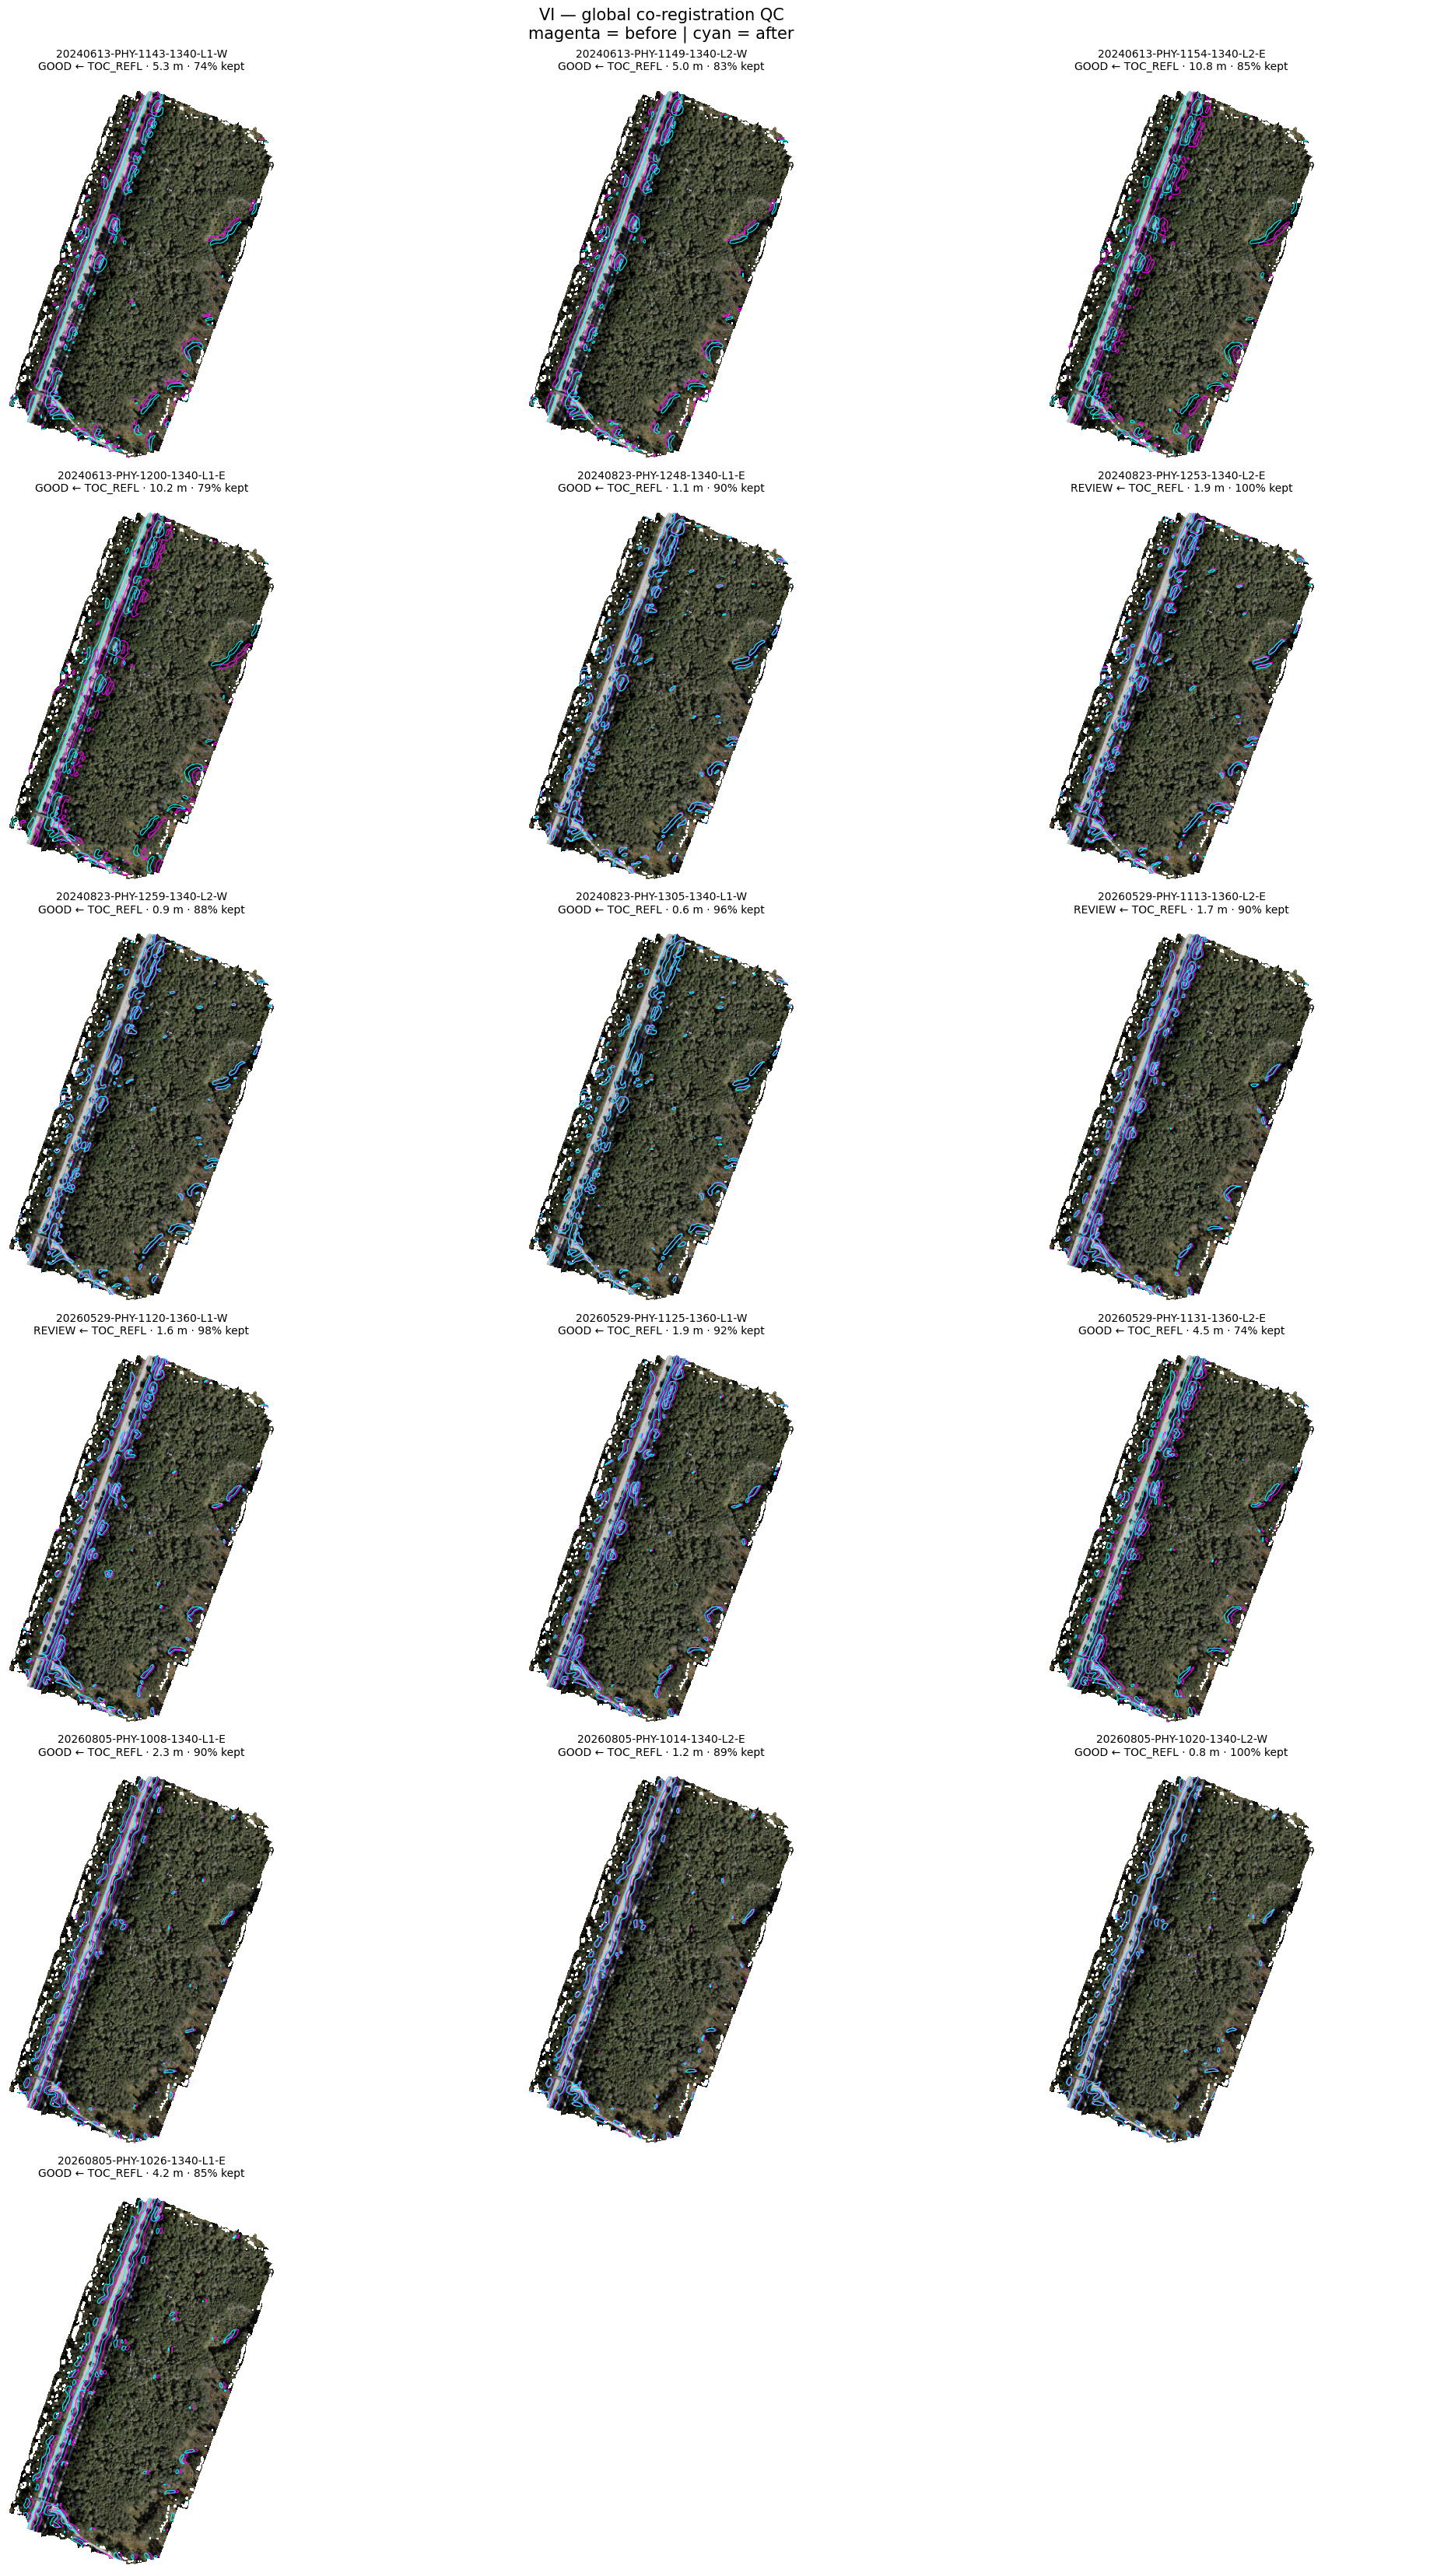

In [80]:
# --- Co-registration diagnostics for all products ---

EDGE_PERCENTILE = 94
EDGE_LINEWIDTH = 0.8
NCOLS = 3


def stretch_rgb(rgb):

    out = np.zeros_like(rgb, dtype="float32")

    for b in range(3):
        valid = np.isfinite(rgb[b])

        if not valid.any():
            continue

        lo, hi = np.nanpercentile(
            rgb[b][valid],
            [2, 98],
        )

        if hi > lo:
            out[b] = np.clip(
                (rgb[b] - lo) / (hi - lo),
                0, 1,
            )

    return np.moveaxis(out, 0, -1)


def plot_edge(ax, edge, valid_mask, extent, color):

    valid = np.isfinite(edge) & valid_mask

    if valid.sum() < 10:
        return

    level = np.nanpercentile(
        edge[valid],
        EDGE_PERCENTILE,
    )

    ax.contour(
        np.ma.masked_where(~valid, edge),
        levels=[level],
        colors=[color],
        linewidths=EDGE_LINEWIDTH,
        origin="upper",
        extent=extent,
        alpha=0.95,
    )


# ------------------------------------------------------------
# UAV background
# ------------------------------------------------------------

with rasterio.open(UAV_RGB_REFERENCE_PATH) as src:

    rgb = (
        src.read(masked=True)
        .astype("float32")
        .filled(np.nan)
    )

    uav_valid = src.dataset_mask() > 0

    ref_transform = src.transform
    ref_crs = src.crs
    ref_shape = (src.height, src.width)

    extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    ]

uav_display = np.clip(
    stretch_rgb(rgb) * 0.78,
    0, 1,
)


# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

def plot_product_diagnostics(folder):

    summary = (
        all_summary_df[
            (all_summary_df["product"] == folder)
            & (all_summary_df["status"] != "FAILED")
        ]
        .copy()
        .reset_index(drop=True)
    )

    if summary.empty:
        print(f"{folder}: no successful images.")
        return

    qc_dir = COREG_DIR_BASE / folder / "qc"

    nrows = int(
        np.ceil(len(summary) / NCOLS)
    )

    fig, axes = plt.subplots(
        nrows,
        NCOLS,
        figsize=(20, 5.5 * nrows),
        squeeze=False,
        constrained_layout=True,
    )

    for ax, row in zip(
        axes.flat,
        summary.itertuples(),
    ):

        # Use the proxy that actually generated the shift.
        source_product = row.registration_source
        source_image = row.source_image

        proxy_path = (
            COREG_DIR_BASE
            / source_product
            / "registration_proxies"
            / f"{Path(source_image).stem}_gradient.tif"
        )

        if not proxy_path.exists():
            ax.set_title("Source proxy missing")
            ax.axis("off")
            continue

        with rasterio.open(proxy_path) as src:

            source = src.read(1).astype("float32")

            before = np.full(
                ref_shape,
                np.nan,
                dtype="float32",
            )

            after = np.full(
                ref_shape,
                np.nan,
                dtype="float32",
            )

            reproject(
                source=source,
                destination=before,
                src_transform=src.transform,
                src_crs=src.crs,
                src_nodata=src.nodata,
                dst_transform=ref_transform,
                dst_crs=ref_crs,
                dst_nodata=np.nan,
                resampling=Resampling.bilinear,
            )

            shifted_transform = (
                Affine.translation(
                    row.x_shift_map,
                    row.y_shift_map,
                )
                * src.transform
            )

            reproject(
                source=source,
                destination=after,
                src_transform=shifted_transform,
                src_crs=src.crs,
                src_nodata=src.nodata,
                dst_transform=ref_transform,
                dst_crs=ref_crs,
                dst_nodata=np.nan,
                resampling=Resampling.bilinear,
            )

        before[~uav_valid] = np.nan
        after[~uav_valid] = np.nan

        ax.imshow(
            uav_display,
            extent=extent,
            origin="upper",
        )

        plot_edge(
            ax, before, uav_valid,
            extent, "magenta",
        )

        plot_edge(
            ax, after, uav_valid,
            extent, "cyan",
        )

        name = acquisition_id(row.image)

        source_text = (
            ""
            if row.registration_source == folder
            else f" ← {row.registration_source}"
        )

        ax.set_title(
            f"{name}\n"
            f"{row.status}{source_text} · "
            f"{row.shift_m:.1f} m · "
            f"{row.retained_pct:.0f}% kept",
            fontsize=10,
        )

        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        ax.set_aspect("equal")
        ax.axis("off")

    for ax in axes.flat[len(summary):]:
        ax.axis("off")

    fig.suptitle(
        f"{folder} — global co-registration QC\n"
        "magenta = before | cyan = after",
        fontsize=15,
    )

    fig.savefig(
        qc_dir / "coreg_diagnostic.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()


# ------------------------------------------------------------
# Run diagnostics
# ------------------------------------------------------------

for folder in FOLDERS:
    plot_product_diagnostics(folder)